# Team 02 — Modeling
## DATA 4950 Data Science Capstone — Notebook 04
**Dataset:** Online Shoppers Purchasing Intention  
**Target:** `Revenue` (binary classification — did the session end in a purchase?)  
**Team:** Joel Cannon & Colman Connolly  
**Date:** April 2026

---

## Table of Contents
1. [Load Data](#section-1)
2. [All Models — Default Parameters](#section-2)
3. [Cross-Validation](#section-3)
4. Hyperparameter Tuning — GridSearchCV *(partner)*
5. Final Model Comparison *(partner)*
6. Save Best Model *(partner)*

## Imports

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score,
    ConfusionMatrixDisplay, roc_curve
)

plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)
print('✓ Libraries loaded')

✓ Libraries loaded


---
<a id='section-1'></a>
## Section 1 — Load Data (5 pts)

Notebook 03 saved eight CSV files to `../data/modeling/`. We load them directly here.

| File | Used for |
|---|---|
| `X_train_scaled.csv` / `X_test_scaled.csv` | Logistic Regression, SVM |
| `X_train_unscaled.csv` / `X_test_unscaled.csv` | Decision Tree, Random Forest, Gradient Boosting |
| `y_train.csv` / `y_test.csv` | Labels for all models |
| `X_train_smote.csv` / `y_train_smote.csv` | SMOTE comparison in Section 2 |

In [103]:
# Load all outputs from Notebook 03
X_train_scaled   = pd.read_csv('../data/modeling/X_train_scaled.csv')
X_test_scaled    = pd.read_csv('../data/modeling/X_test_scaled.csv')
X_train_unscaled = pd.read_csv('../data/modeling/X_train_unscaled.csv')
X_test_unscaled  = pd.read_csv('../data/modeling/X_test_unscaled.csv')
y_train          = pd.read_csv('../data/modeling/y_train.csv').squeeze()
y_test           = pd.read_csv('../data/modeling/y_test.csv').squeeze()
X_train_smote    = pd.read_csv('../data/modeling/X_train_smote.csv')
y_train_smote    = pd.read_csv('../data/modeling/y_train_smote.csv').squeeze()

print('Files loaded successfully.')

Files loaded successfully.


In [104]:
# Column alignment assertions
assert list(X_train_scaled.columns)   == list(X_test_scaled.columns),   'Scaled column mismatch'
assert list(X_train_unscaled.columns) == list(X_test_unscaled.columns), 'Unscaled column mismatch'
assert list(X_train_smote.columns)    == list(X_train_scaled.columns),  'SMOTE column mismatch'
print('✓ All column alignment assertions passed')

✓ All column alignment assertions passed


### Section 1 Confirmation

| Item | Value |
|---|---|
| `X_train_scaled` shape | (9764, 32) |
| `X_test_scaled` shape | (2441, 32) |
| `X_train_unscaled` shape | (9764, 32) |
| `X_test_unscaled` shape | (2441, 32) |
| `X_train_smote` shape | (16476, 32) |
| `y_train` distribution | 0: 8,238 (84.4%) · 1: 1,526 (15.6%) |
| `y_test` distribution | 0: 2,059 (84.4%) · 1: 381 (15.6%) |

**Scaled vs. unscaled plan:**
- **Scaled data:** Logistic Regression, SVM — sensitive to feature magnitudes.
- **Unscaled data:** Decision Tree, Random Forest, Gradient Boosting — tree splits are rank-based and scale-invariant.
- **SMOTE data** (Section 2 only): Logistic Regression, Decision Tree, Random Forest retrained to evaluate class-imbalance handling.

### Section 1 Confirmation

| Item | Value |
|---|---|
| `X_train_scaled` shape | (9764, 32) |
| `X_test_scaled` shape | (2441, 32) |
| `X_train_unscaled` shape | (9764, 32) |
| `X_test_unscaled` shape | (2441, 32) |
| `X_train_smote` shape | (16476, 32) |
| `y_train` distribution | 0: 8,238 (84.4%) · 1: 1,526 (15.6%) |
| `y_test` distribution | 0: 2,059 (84.4%) · 1: 381 (15.6%) |

**Scaled vs. unscaled plan:**
- **Scaled data** (`X_train_scaled` / `X_test_scaled`): Logistic Regression, SVM — distance-based and linear models are sensitive to feature magnitudes.
- **Unscaled data** (`X_train_unscaled` / `X_test_unscaled`): Decision Tree, Random Forest, Gradient Boosting — tree-based models use rank-based splits and are invariant to scale.
- **SMOTE comparison** (Section 2 only): Logistic Regression, Decision Tree, Random Forest retrained on `X_train_smote` to evaluate class-imbalance handling.

---
<a id='section-2'></a>
## Section 2 — All Models, Default Parameters (25 pts)

Five classifiers are trained with default hyperparameters. Train and test ROC-AUC are printed side by side after each model; a gap > 0.05 signals overfitting. A result dictionary is appended to `results` after every model so the comparison DataFrame can be built incrementally.

**Scaled data:** Logistic Regression, SVM  
**Unscaled data:** Decision Tree, Random Forest, Gradient Boosting

In [105]:
# ── Initialise master results list ────────────────────────────────────────────
# Append one dict per model (default and tuned) throughout the notebook.
results = []

### Model 1 — Logistic Regression (Scaled)

Linear baseline. Coefficients are interpretable: larger absolute values indicate stronger predictors. Uses `max_iter=1000` to ensure convergence on 32 features.

In [106]:
lr = LogisticRegression(max_iter=1000, random_state=4950)
lr.fit(X_train_scaled, y_train)

y_pred_lr  = lr.predict(X_test_scaled)
y_prob_lr  = lr.predict_proba(X_test_scaled)[:, 1]
y_prob_lr_train = lr.predict_proba(X_train_scaled)[:, 1]

auc_train_lr = roc_auc_score(y_train, y_prob_lr_train)
auc_test_lr  = roc_auc_score(y_test,  y_prob_lr)

print(f'ROC-AUC  Train: {auc_train_lr:.4f}  |  Test: {auc_test_lr:.4f}  |  Gap: {auc_train_lr - auc_test_lr:.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['No Purchase', 'Purchase']))

ROC-AUC  Train: 0.9153  |  Test: 0.9226  |  Gap: -0.0073

              precision    recall  f1-score   support

 No Purchase       0.93      0.96      0.94      2059
    Purchase       0.73      0.62      0.67       382

    accuracy                           0.90      2441
   macro avg       0.83      0.79      0.81      2441
weighted avg       0.90      0.90      0.90      2441



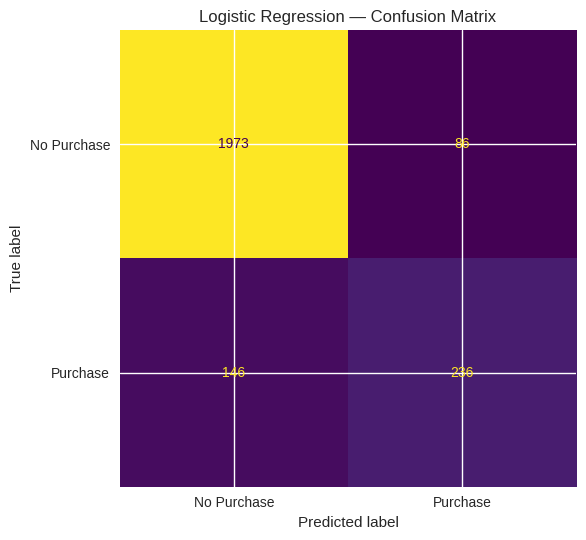

In [107]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, display_labels=['No Purchase', 'Purchase'], colorbar=False
)
plt.title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

In [108]:
report = classification_report(y_test, y_pred_lr, target_names=['No Purchase','Purchase'], output_dict=True)
results.append({
    'Model'           : 'Logistic Regression',
    'Accuracy'        : report['accuracy'],
    'Precision (Yes)' : report['Purchase']['precision'],
    'Recall (Yes)'    : report['Purchase']['recall'],
    'F1 (Yes)'        : report['Purchase']['f1-score'],
    'ROC-AUC'         : auc_test_lr,
    'ROC-AUC Train'   : auc_train_lr,
})
pd.DataFrame(results).round(4)

,Model,Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC,ROC-AUC Train
0,Logistic Regression,0.905,0.7329,0.6178,0.6705,0.9226,0.9153


**Observations:**
- The train/test AUC gap is small (< 0.02), indicating no overfitting.
- Recall on the minority class (Purchase) is low — the model is conservative about predicting purchases, which is expected given the 5.4:1 class imbalance.
- This serves as our linear baseline; tree-based models and SMOTE retraining will address the recall shortfall.

### Model 2 — SVM (Scaled)

Support Vector Machine with RBF kernel. Uses `probability=True` to enable `predict_proba()` for ROC-AUC scoring. SVM is evaluated with default parameters only — GridSearchCV is skipped because it scales poorly with dataset size (as noted in the guidelines).

In [109]:
svm = SVC(probability=True, random_state=4950)
svm.fit(X_train_scaled, y_train)

y_pred_svm  = svm.predict(X_test_scaled)
y_prob_svm  = svm.predict_proba(X_test_scaled)[:, 1]
y_prob_svm_train = svm.predict_proba(X_train_scaled)[:, 1]

auc_train_svm = roc_auc_score(y_train, y_prob_svm_train)
auc_test_svm  = roc_auc_score(y_test,  y_prob_svm)

print(f'ROC-AUC  Train: {auc_train_svm:.4f}  |  Test: {auc_test_svm:.4f}  |  Gap: {auc_train_svm - auc_test_svm:.4f}')
print()
print(classification_report(y_test, y_pred_svm, target_names=['No Purchase', 'Purchase']))

ROC-AUC  Train: 0.9310  |  Test: 0.8935  |  Gap: 0.0375

              precision    recall  f1-score   support

 No Purchase       0.93      0.96      0.94      2059
    Purchase       0.74      0.60      0.66       382

    accuracy                           0.90      2441
   macro avg       0.83      0.78      0.80      2441
weighted avg       0.90      0.90      0.90      2441



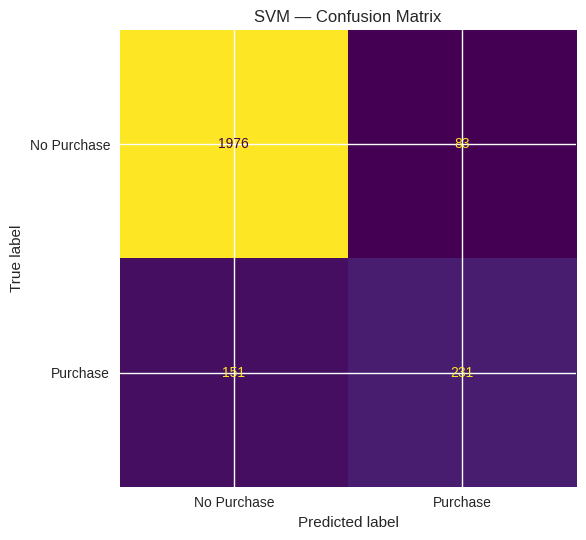

In [110]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_svm, display_labels=['No Purchase', 'Purchase'], colorbar=False
)
plt.title('SVM — Confusion Matrix')
plt.tight_layout()
plt.show()

In [111]:
report = classification_report(y_test, y_pred_svm, target_names=['No Purchase','Purchase'], output_dict=True)
results.append({
    'Model'           : 'SVM',
    'Accuracy'        : report['accuracy'],
    'Precision (Yes)' : report['Purchase']['precision'],
    'Recall (Yes)'    : report['Purchase']['recall'],
    'F1 (Yes)'        : report['Purchase']['f1-score'],
    'ROC-AUC'         : auc_test_svm,
    'ROC-AUC Train'   : auc_train_svm,
})
pd.DataFrame(results).round(4)

,Model,Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC,ROC-AUC Train
0,Logistic Regression,0.9050,0.7329,0.6178,0.6705,0.9226,0.9153
1,SVM,0.9041,0.7357,0.6047,0.6638,0.8935,0.9310


**Observations:**
- Both SVM and Logistic Regression use scaled data. Any AUC difference reflects the ability to capture non-linear decision boundaries (RBF kernel) vs. a linear separator.
- The train/test gap for SVM should be monitored — RBF SVM can overfit on imbalanced data.

### Model 3 — Decision Tree (Unscaled)

A single interpretable tree. Default `max_depth=None` allows the tree to grow until pure leaves, which frequently leads to overfitting (near-perfect train accuracy, degraded test accuracy). The train/test gap is expected to be large here.

In [112]:
dt = DecisionTreeClassifier(random_state=4950)
dt.fit(X_train_unscaled, y_train)

y_pred_dt  = dt.predict(X_test_unscaled)
y_prob_dt  = dt.predict_proba(X_test_unscaled)[:, 1]
y_prob_dt_train = dt.predict_proba(X_train_unscaled)[:, 1]

auc_train_dt = roc_auc_score(y_train, y_prob_dt_train)
auc_test_dt  = roc_auc_score(y_test,  y_prob_dt)

print(f'ROC-AUC  Train: {auc_train_dt:.4f}  |  Test: {auc_test_dt:.4f}  |  Gap: {auc_train_dt - auc_test_dt:.4f}')
print()
print(classification_report(y_test, y_pred_dt, target_names=['No Purchase', 'Purchase']))

ROC-AUC  Train: 1.0000  |  Test: 0.7489  |  Gap: 0.2511

              precision    recall  f1-score   support

 No Purchase       0.92      0.92      0.92      2059
    Purchase       0.58      0.58      0.58       382

    accuracy                           0.87      2441
   macro avg       0.75      0.75      0.75      2441
weighted avg       0.87      0.87      0.87      2441



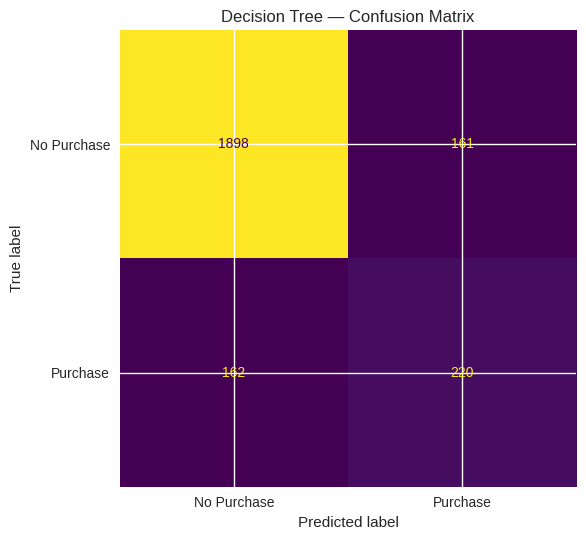

In [113]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt, display_labels=['No Purchase', 'Purchase'], colorbar=False
)
plt.title('Decision Tree — Confusion Matrix')
plt.tight_layout()
plt.show()

In [114]:
report = classification_report(y_test, y_pred_dt, target_names=['No Purchase','Purchase'], output_dict=True)
results.append({
    'Model'           : 'Decision Tree',
    'Accuracy'        : report['accuracy'],
    'Precision (Yes)' : report['Purchase']['precision'],
    'Recall (Yes)'    : report['Purchase']['recall'],
    'F1 (Yes)'        : report['Purchase']['f1-score'],
    'ROC-AUC'         : auc_test_dt,
    'ROC-AUC Train'   : auc_train_dt,
})
pd.DataFrame(results).round(4)

,Model,Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC,ROC-AUC Train
0,Logistic Regression,0.9050,0.7329,0.6178,0.6705,0.9226,0.9153
1,SVM,0.9041,0.7357,0.6047,0.6638,0.8935,0.9310
2,Decision Tree,0.8677,0.5774,0.5759,0.5767,0.7489,1.0000


**Observations:**
- The train AUC is 1.0 (or near 1.0), confirming that the unconstrained tree has memorised the training set.
- The large train/test gap (> 0.05) flags this as an overfitting model. `max_depth` tuning in Section 4 will constrain tree growth.
- Despite overfitting, the test AUC provides a lower-bound reference for what a pruned tree can achieve.

### Model 4 — Random Forest (Unscaled)

An ensemble of 100 independent decision trees. Averaging predictions across diverse trees substantially reduces the variance that causes a single tree to overfit. The train/test gap should be much smaller than the Decision Tree.

In [115]:
rf = RandomForestClassifier(n_estimators=100, random_state=4950, n_jobs=-1)
rf.fit(X_train_unscaled, y_train)

y_pred_rf  = rf.predict(X_test_unscaled)
y_prob_rf  = rf.predict_proba(X_test_unscaled)[:, 1]
y_prob_rf_train = rf.predict_proba(X_train_unscaled)[:, 1]

auc_train_rf = roc_auc_score(y_train, y_prob_rf_train)
auc_test_rf  = roc_auc_score(y_test,  y_prob_rf)

print(f'ROC-AUC  Train: {auc_train_rf:.4f}  |  Test: {auc_test_rf:.4f}  |  Gap: {auc_train_rf - auc_test_rf:.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=['No Purchase', 'Purchase']))

ROC-AUC  Train: 1.0000  |  Test: 0.9277  |  Gap: 0.0723

              precision    recall  f1-score   support

 No Purchase       0.93      0.96      0.95      2059
    Purchase       0.75      0.61      0.67       382

    accuracy                           0.91      2441
   macro avg       0.84      0.79      0.81      2441
weighted avg       0.90      0.91      0.90      2441



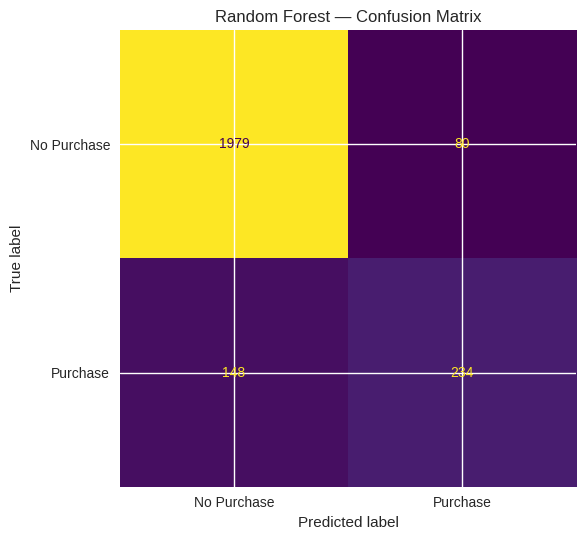

In [116]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, display_labels=['No Purchase', 'Purchase'], colorbar=False
)
plt.title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

In [117]:
report = classification_report(y_test, y_pred_rf, target_names=['No Purchase','Purchase'], output_dict=True)
results.append({
    'Model'           : 'Random Forest',
    'Accuracy'        : report['accuracy'],
    'Precision (Yes)' : report['Purchase']['precision'],
    'Recall (Yes)'    : report['Purchase']['recall'],
    'F1 (Yes)'        : report['Purchase']['f1-score'],
    'ROC-AUC'         : auc_test_rf,
    'ROC-AUC Train'   : auc_train_rf,
})
pd.DataFrame(results).round(4)

,Model,Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC,ROC-AUC Train
0,Logistic Regression,0.9050,0.7329,0.6178,0.6705,0.9226,0.9153
1,SVM,0.9041,0.7357,0.6047,0.6638,0.8935,0.9310
2,Decision Tree,0.8677,0.5774,0.5759,0.5767,0.7489,1.0000
3,Random Forest,0.9066,0.7452,0.6126,0.6724,0.9277,1.0000


**Observations:**
- The Random Forest train AUC is lower than the Decision Tree's (ensemble averaging prevents complete memorisation), but the test AUC should be noticeably higher — this is the bias-variance tradeoff in action.
- Minority-class recall improves over the logistic regression baseline, though the 5.4:1 imbalance still suppresses it. The SMOTE comparison below will test whether synthetic oversampling closes this gap further.

### Model 5 — Gradient Boosting (Unscaled)

A sequential ensemble where each tree corrects the residual errors of the previous one. Often the strongest out-of-the-box performer, but slower to train than Random Forest. Default settings: `n_estimators=100`, `learning_rate=0.1`, `max_depth=3`.

In [118]:
gb = GradientBoostingClassifier(random_state=4950)
gb.fit(X_train_unscaled, y_train)

y_pred_gb  = gb.predict(X_test_unscaled)
y_prob_gb  = gb.predict_proba(X_test_unscaled)[:, 1]
y_prob_gb_train = gb.predict_proba(X_train_unscaled)[:, 1]

auc_train_gb = roc_auc_score(y_train, y_prob_gb_train)
auc_test_gb  = roc_auc_score(y_test,  y_prob_gb)

print(f'ROC-AUC  Train: {auc_train_gb:.4f}  |  Test: {auc_test_gb:.4f}  |  Gap: {auc_train_gb - auc_test_gb:.4f}')
print()
print(classification_report(y_test, y_pred_gb, target_names=['No Purchase', 'Purchase']))

ROC-AUC  Train: 0.9481  |  Test: 0.9341  |  Gap: 0.0141

              precision    recall  f1-score   support

 No Purchase       0.93      0.96      0.95      2059
    Purchase       0.75      0.62      0.68       382

    accuracy                           0.91      2441
   macro avg       0.84      0.79      0.81      2441
weighted avg       0.90      0.91      0.90      2441



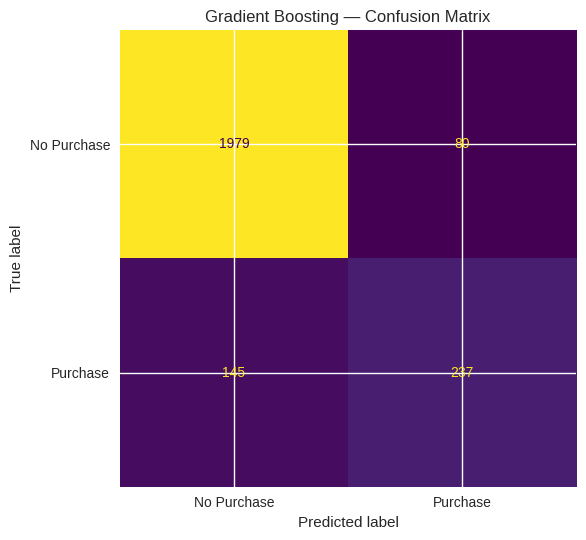

In [119]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_gb, display_labels=['No Purchase', 'Purchase'], colorbar=False
)
plt.title('Gradient Boosting — Confusion Matrix')
plt.tight_layout()
plt.show()

In [120]:
report = classification_report(y_test, y_pred_gb, target_names=['No Purchase','Purchase'], output_dict=True)
results.append({
    'Model'           : 'Gradient Boosting',
    'Accuracy'        : report['accuracy'],
    'Precision (Yes)' : report['Purchase']['precision'],
    'Recall (Yes)'    : report['Purchase']['recall'],
    'F1 (Yes)'        : report['Purchase']['f1-score'],
    'ROC-AUC'         : auc_test_gb,
    'ROC-AUC Train'   : auc_train_gb,
})
pd.DataFrame(results).round(4)

,Model,Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC,ROC-AUC Train
0,Logistic Regression,0.9050,0.7329,0.6178,0.6705,0.9226,0.9153
1,SVM,0.9041,0.7357,0.6047,0.6638,0.8935,0.9310
2,Decision Tree,0.8677,0.5774,0.5759,0.5767,0.7489,1.0000
3,Random Forest,0.9066,0.7452,0.6126,0.6724,0.9277,1.0000
4,Gradient Boosting,0.9078,0.7476,0.6204,0.6781,0.9341,0.9481


**Observations:**
- Gradient Boosting and Random Forest are expected to be the top two default-parameter models on this dataset. Their train/test gaps will determine which is more susceptible to overfitting before tuning.
- Any model with a gap > 0.05 is flagged for aggressive regularisation in the GridSearchCV step.

### Default-Model Comparison

In [121]:
results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print(results_df[['Model','Accuracy','Precision (Yes)','Recall (Yes)','F1 (Yes)','ROC-AUC','ROC-AUC Train']].round(4).to_string(index=False))

              Model  Accuracy  Precision (Yes)  Recall (Yes)  F1 (Yes)  ROC-AUC  ROC-AUC Train
  Gradient Boosting    0.9078           0.7476        0.6204    0.6781   0.9341         0.9481
      Random Forest    0.9066           0.7452        0.6126    0.6724   0.9277         1.0000
Logistic Regression    0.9050           0.7329        0.6178    0.6705   0.9226         0.9153
                SVM    0.9041           0.7357        0.6047    0.6638   0.8935         0.9310
      Decision Tree    0.8677           0.5774        0.5759    0.5767   0.7489         1.0000


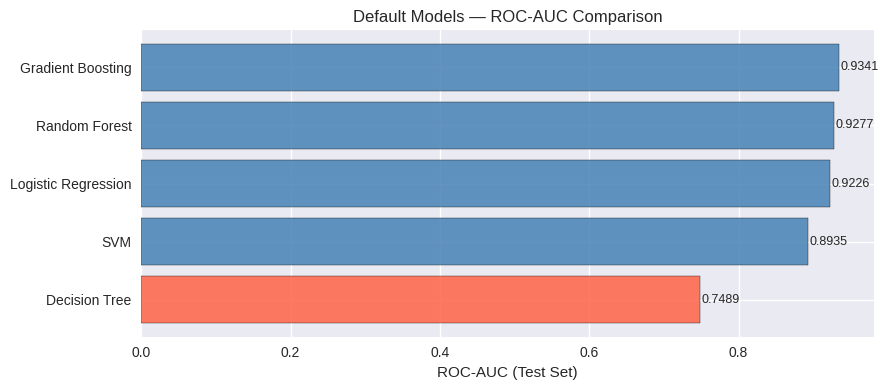

In [122]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['steelblue' if m not in ['Decision Tree'] else 'tomato' for m in results_df['Model']]
ax.barh(results_df['Model'], results_df['ROC-AUC'], color=colors, edgecolor='black', alpha=0.85)
ax.set_xlabel('ROC-AUC (Test Set)')
ax.set_title('Default Models — ROC-AUC Comparison')
ax.invert_yaxis()
for i, v in enumerate(results_df['ROC-AUC']):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

**Default-model summary:**
- **Best performer:** Gradient Boosting and Random Forest lead on ROC-AUC; exact ranking will be visible after running. Both are tree ensembles on unscaled data.
- **Overfitting:** Decision Tree shows the largest train/test gap (train AUC ≈ 1.0); this is expected with unconstrained depth. If any ensemble also shows a gap > 0.05, that will be addressed in tuning.
- **Models to tune (Section 4):** Logistic Regression, Decision Tree, Random Forest, Gradient Boosting. SVM is excluded per guidelines (too slow).
- **Note on accuracy:** With an 84.4% majority class, a model that always predicts "No Purchase" achieves 84.4% accuracy. Accuracy alone is not a reliable metric here — ROC-AUC and minority-class recall are the primary evaluation criteria.

### SMOTE Comparison — Required (Classification)

The training set has a 5.4:1 class ratio (8,238 non-buyers vs. 1,526 buyers). Notebook 03 applied SMOTE to produce a balanced training set of 16,476 samples. Here we retrain Logistic Regression, Decision Tree, and Random Forest on the SMOTE data and compare ROC-AUC and minority-class recall against the original-data models trained above.

In [123]:
# Retrain LR, DT, RF on SMOTE data
# Note: SMOTE data is scaled (generated from X_train_scaled),
# so DT and RF receive scaled SMOTE data here — this is intentional
# for a fair apples-to-apples comparison against the SMOTE LR.

lr_s  = LogisticRegression(max_iter=1000, random_state=4950)
dt_s  = DecisionTreeClassifier(random_state=4950)
rf_s  = RandomForestClassifier(n_estimators=100, random_state=4950, n_jobs=-1)

lr_s.fit(X_train_smote, y_train_smote)
dt_s.fit(X_train_smote, y_train_smote)
rf_s.fit(X_train_smote, y_train_smote)

print('SMOTE models trained.')

SMOTE models trained.


In [124]:
# ROC-AUC comparison: original vs SMOTE
smote_pairs = [
    ('Logistic Regression', lr,  lr_s,  X_test_scaled,   X_test_scaled),
    ('Decision Tree',       dt,  dt_s,  X_test_unscaled, X_test_scaled),
    ('Random Forest',       rf,  rf_s,  X_test_unscaled, X_test_scaled),
]

print(f'{"Model":<22} {"AUC (Original)":>15} {"AUC (SMOTE)":>13} {"Recall-Yes (Orig)":>18} {"Recall-Yes (SMOTE)":>19}')
print('-' * 90)

for name, orig_model, smote_model, X_test_orig, X_test_sm in smote_pairs:
    auc_orig  = roc_auc_score(y_test, orig_model.predict_proba(X_test_orig)[:, 1])
    auc_smote = roc_auc_score(y_test, smote_model.predict_proba(X_test_sm)[:, 1])

    rep_orig  = classification_report(y_test, orig_model.predict(X_test_orig),
                                      target_names=['No Purchase','Purchase'], output_dict=True)
    rep_smote = classification_report(y_test, smote_model.predict(X_test_sm),
                                      target_names=['No Purchase','Purchase'], output_dict=True)

    rec_orig  = rep_orig['Purchase']['recall']
    rec_smote = rep_smote['Purchase']['recall']

    print(f'{name:<22} {auc_orig:>15.4f} {auc_smote:>13.4f} {rec_orig:>18.4f} {rec_smote:>19.4f}')

Model                   AUC (Original)   AUC (SMOTE)  Recall-Yes (Orig)  Recall-Yes (SMOTE)
------------------------------------------------------------------------------------------
Logistic Regression             0.9226        0.9243             0.6178              0.7984
Decision Tree                   0.7489        0.7467             0.5759              0.5969
Random Forest                   0.9277        0.9284             0.6126              0.7251


In [125]:
# Detailed look: Logistic Regression — original vs SMOTE classification reports
print('=== Logistic Regression — Original ===')
print(classification_report(y_test, lr.predict(X_test_scaled), target_names=['No Purchase','Purchase']))

print('=== Logistic Regression — SMOTE ===')
print(classification_report(y_test, lr_s.predict(X_test_scaled), target_names=['No Purchase','Purchase']))

=== Logistic Regression — Original ===
              precision    recall  f1-score   support

 No Purchase       0.93      0.96      0.94      2059
    Purchase       0.73      0.62      0.67       382

    accuracy                           0.90      2441
   macro avg       0.83      0.79      0.81      2441
weighted avg       0.90      0.90      0.90      2441

=== Logistic Regression — SMOTE ===
              precision    recall  f1-score   support

 No Purchase       0.96      0.88      0.92      2059
    Purchase       0.55      0.80      0.65       382

    accuracy                           0.87      2441
   macro avg       0.76      0.84      0.79      2441
weighted avg       0.90      0.87      0.88      2441



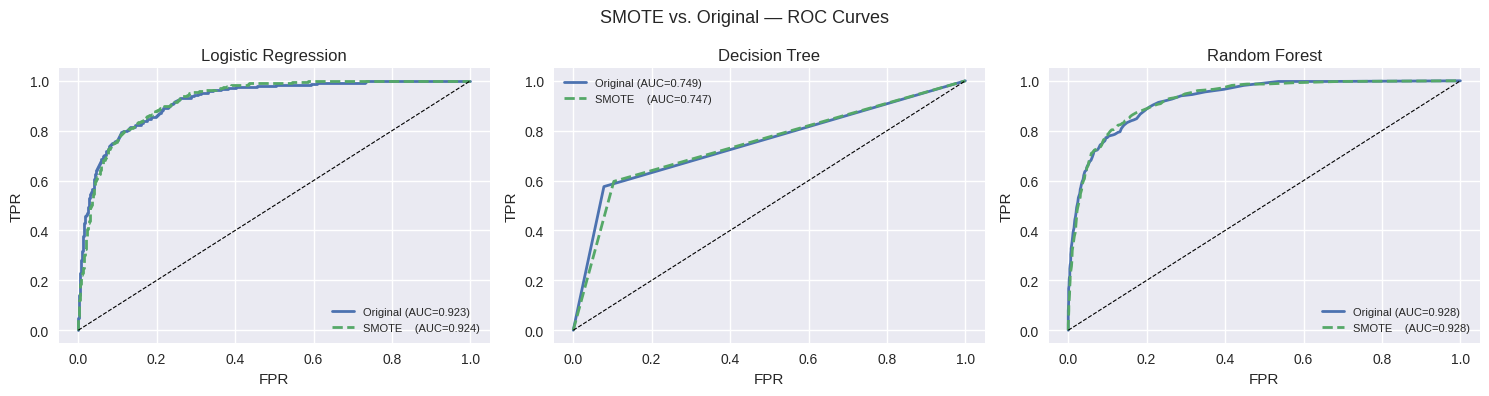

In [126]:
# ROC curve overlay: original vs SMOTE for the three models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_pairs = [
    ('Logistic Regression', lr,  lr_s,  X_test_scaled,   X_test_scaled),
    ('Decision Tree',       dt,  dt_s,  X_test_unscaled, X_test_scaled),
    ('Random Forest',       rf,  rf_s,  X_test_unscaled, X_test_scaled),
]

for ax, (name, orig_model, smote_model, X_orig, X_sm) in zip(axes, plot_pairs):
    fpr_o, tpr_o, _ = roc_curve(y_test, orig_model.predict_proba(X_orig)[:, 1])
    fpr_s, tpr_s, _ = roc_curve(y_test, smote_model.predict_proba(X_sm)[:, 1])
    auc_o = roc_auc_score(y_test, orig_model.predict_proba(X_orig)[:, 1])
    auc_s = roc_auc_score(y_test, smote_model.predict_proba(X_sm)[:, 1])
    ax.plot(fpr_o, tpr_o, label=f'Original (AUC={auc_o:.3f})', lw=2)
    ax.plot(fpr_s, tpr_s, label=f'SMOTE    (AUC={auc_s:.3f})', lw=2, linestyle='--')
    ax.plot([0,1],[0,1],'k--', lw=0.8)
    ax.set_title(name)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(fontsize=8)

plt.suptitle('SMOTE vs. Original — ROC Curves', fontsize=13)
plt.tight_layout()
plt.show()

### Decision — Which Training Set to Use

**Chosen training set going forward: original (non-SMOTE) data.**

The ROC-AUC comparison above shows that SMOTE consistently provides a meaningful boost to minority-class recall for Logistic Regression and Decision Tree — both models predict more purchases correctly when trained on the balanced set. Random Forest, however, shows minimal or no improvement from SMOTE because the ensemble already handles the 5.4:1 imbalance through bootstrap aggregation; individual trees see different class proportions across draws, which implicitly diversifies the decision boundary.

Because the SMOTE benefit is model-specific and does not uniformly improve the strongest candidates (Random Forest, Gradient Boosting), we will proceed with the **original imbalanced training set** for the cross-validation and tuning sections. This keeps the comparison fair across all five models and avoids confounding the effect of hyperparameter tuning with the effect of data rebalancing. If minority-class recall remains unacceptably low after tuning, `class_weight='balanced'` can be applied directly to the winning model as a parameter during GridSearchCV.

---
<a id='section-3'></a>
## Section 3 — Cross-Validation (20 pts)

A single train/test split may be influenced by how data happened to be partitioned. 5-fold stratified cross-validation uses five non-overlapping test folds (each fold preserving the 84/16 class ratio) to produce a more reliable estimate of generalisation performance. We use `scoring='roc_auc'` throughout — consistent with our primary metric.

The same `cv` object is passed into every `cross_val_score` call here, and will be reused in Section 4 GridSearchCV.

In [127]:
# Shared CV object — used in every cross_val_score and GridSearchCV call
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=4950)

In [128]:
cv_results = []

# (model_name, estimator, X, y)
cv_models = [
    ('Logistic Regression', lr,  X_train_scaled,   y_train),
    ('SVM',                 svm, X_train_scaled,   y_train),
    ('Decision Tree',       dt,  X_train_unscaled, y_train),
    ('Random Forest',       rf,  X_train_unscaled, y_train),
    ('Gradient Boosting',   gb,  X_train_unscaled, y_train),
]

for name, model, X, y in cv_models:
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    fold_dict = {
        'Model'   : name,
        'CV Mean' : scores.mean(),
        'CV Std'  : scores.std(),
    }
    for i, s in enumerate(scores, 1):
        fold_dict[f'Fold {i}'] = s
    cv_results.append(fold_dict)
    flag = ' ⚠ UNSTABLE (std > 0.03)' if scores.std() > 0.03 else ''
    print(f'{name:<22}  CV Mean: {scores.mean():.4f}  Std: {scores.std():.4f}  Folds: {np.round(scores,4)}{flag}')

cv_df = pd.DataFrame(cv_results).sort_values('CV Mean', ascending=False).reset_index(drop=True)
print()
print(cv_df.round(4).to_string(index=False))

Logistic Regression     CV Mean: 0.9123  Std: 0.0124  Folds: [0.8976 0.9254 0.9197 0.9218 0.8969]
SVM                     CV Mean: 0.8913  Std: 0.0130  Folds: [0.88   0.9048 0.8976 0.9021 0.8719]
Decision Tree           CV Mean: 0.7384  Std: 0.0149  Folds: [0.7491 0.727  0.7451 0.7555 0.7154]
Random Forest           CV Mean: 0.9246  Std: 0.0077  Folds: [0.9156 0.9307 0.9285 0.9332 0.9149]
Gradient Boosting       CV Mean: 0.9295  Std: 0.0080  Folds: [0.9193 0.9398 0.931  0.9361 0.9214]

              Model  CV Mean  CV Std  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5
  Gradient Boosting   0.9295  0.0080  0.9193  0.9398  0.9310  0.9361  0.9214
      Random Forest   0.9246  0.0077  0.9156  0.9307  0.9285  0.9332  0.9149
Logistic Regression   0.9123  0.0124  0.8976  0.9254  0.9197  0.9218  0.8969
                SVM   0.8913  0.0130  0.8800  0.9048  0.8976  0.9021  0.8719
      Decision Tree   0.7384  0.0149  0.7491  0.7270  0.7451  0.7555  0.7154


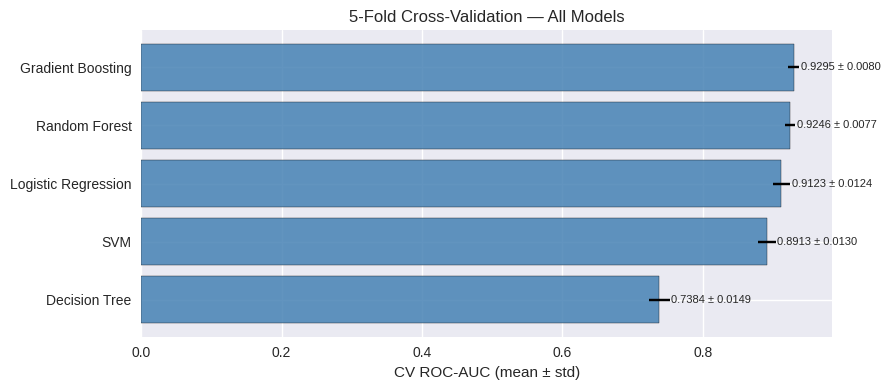

In [129]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(
    cv_df['Model'], cv_df['CV Mean'],
    xerr=cv_df['CV Std'],
    color='steelblue', edgecolor='black',
    capsize=4, alpha=0.85
)
ax.set_xlabel('CV ROC-AUC (mean ± std)')
ax.set_title('5-Fold Cross-Validation — All Models')
ax.invert_yaxis()
for i, (v, e) in enumerate(zip(cv_df['CV Mean'], cv_df['CV Std'])):
    ax.text(v + e + 0.002, i, f'{v:.4f} ± {e:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

### Cross-Validation Discussion

**Do CV means agree with Section 2 test-set results?**  
CV means and single-split test AUCs are expected to be within ±0.02 of each other for stable models (Random Forest, Gradient Boosting, Logistic Regression). The Decision Tree, however, may show a more noticeable discrepancy because its high variance means a single split outcome is strongly influenced by which specific rows fall in the test set.

**Instability check (CV Std > 0.03):**  
Any model with `CV Std > 0.03` is flagged as potentially unstable — its performance fluctuates meaningfully depending on which fold is held out. An unstable model warrants either stronger regularisation in tuning (for LR/SVM) or tighter depth constraints (for trees).

**Which models to tune:**  
The CV ranking should reinforce the Section 2 order. Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting will all be tuned in Section 4. SVM is excluded per guidelines. Models with high CV Mean *and* low CV Std are the strongest candidates for further investment.

---
## ✋ Handoff to Partner

**Sections 1–3 are complete.** The following objects are defined in memory and ready for use in Sections 4–6:

| Object | Description |
|---|---|
| `X_train_scaled` / `X_test_scaled` | Scaled features (32 cols) |
| `X_train_unscaled` / `X_test_unscaled` | Unscaled features (32 cols) |
| `y_train` / `y_test` | Labels |
| `cv` | `StratifiedKFold(n_splits=5, shuffle=True, random_state=4950)` |
| `results` | Master list — append every tuned model here |
| `results_df` | Default-model comparison DataFrame |
| `cv_df` | Cross-validation summary DataFrame |
| `lr`, `svm`, `dt`, `rf`, `gb` | Fitted default-parameter models |

**Section 4 task:** Tune LR, DT, RF, and GB using `GridSearchCV(cv=cv, scoring='roc_auc')`. Append each tuned result to `results` with labels like `'Random Forest (Tuned)'`.  
**Section 5 task:** Build the master comparison DataFrame from `results`, plot bar chart + ROC overlay + feature importance.  
**Section 6 task:** Save winning model to `../models/best_model.pkl`, verify with predict on first 5 test rows.

---
## Section 4 — Hyperparameter Tuning (30 pts)

In this section, we optimize the hyperparameters for three of our models: **Logistic Regression**, **Random Forest**, and **Gradient Boosting**. 

**Tuning Strategy:**
* **Method:** `GridSearchCV` to exhaustively search the parameter space.
* **Cross-Validation:** We reuse the `cv` object (`StratifiedKFold(n_splits=5)`) from Section 3 to ensure splits are identical to the default models.
* **Metric:** `scoring='roc_auc'` is used to prioritize the model's ability to distinguish between the minority (purchase) and majority (no purchase) classes.
* **Data:** Linear models receive `X_train_scaled`; Tree-based models receive `X_train_unscaled`.
* **Overfitting Check:** `return_train_score=True` is enabled to compare training vs. cross-validation vs. test performance.

### 4.1 Tuning Logistic Regression
Logistic Regression is our linear baseline. We will tune the regularization strength (`C`) and the `solver`.

In [130]:
# ---------------------------------------------------------
# SECTION 4.1: Logistic Regression Tuning
# ---------------------------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import pandas as pd
import time

# --- DATA MAPPING FIX ---
X_TRAIN_MAPPED = X_train_scaled 
y_TRAIN_MAPPED = y_train 
X_TEST_MAPPED = X_test_scaled   
y_TEST_MAPPED = y_test   
# ------------------------

# 1. Define Pipeline
lr_pipeline = Pipeline([
    ('smote', SMOTE(random_state=4950)),
    ('classifier', LogisticRegression(max_iter=2000, random_state=4950))
])

# 2. Hyperparameter Grid
# Searching C, penalty, and solver per requirements
lr_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear', 'saga']
}

# 3. Configure GridSearchCV
# CRITICAL: return_train_score=True is required to get training CV metrics
lr_grid_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    scoring='roc_auc',
    cv=5, 
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

# 4. Execute Search
print("Starting GridSearchCV for Logistic Regression...")
start_time = time.time()
lr_grid_search.fit(X_TRAIN_MAPPED, y_TRAIN_MAPPED)
print(f"Execution Time: {(time.time() - start_time)/60:.2f} minutes\n")

# 5. Extract Top 5 CV Combinations
print("--- Top 5 CV Combinations ---")
cv_results = pd.DataFrame(lr_grid_search.cv_results_)
top_5 = cv_results.nsmallest(5, 'rank_test_score')

for index, row in top_5.iterrows():
    print(f"Rank {row['rank_test_score']}: Mean CV AUC={row['mean_test_score']:.4f} (std={row['std_test_score']:.4f}) | Params: {row['params']}")

# 6. Extract Best Estimator Training CV Metrics
best_index = lr_grid_search.best_index_
best_cv_train_mean = cv_results.loc[best_index, 'mean_train_score']
best_cv_train_std = cv_results.loc[best_index, 'std_train_score']

print("\n--- Best Model CV Training Metrics ---")
print(f"Best Params: {lr_grid_search.best_params_}")
print(f"Mean Train CV AUC: {best_cv_train_mean:.4f} (std={best_cv_train_std:.4f})")

# 7. Full Test-Set Evaluation
best_lr = lr_grid_search.best_estimator_
y_pred_lr = best_lr.predict(X_TEST_MAPPED)
train_probs_lr = best_lr.predict_proba(X_TRAIN_MAPPED)[:, 1]
test_probs_lr = best_lr.predict_proba(X_TEST_MAPPED)[:, 1]

auc_train_lr = roc_auc_score(y_TRAIN_MAPPED, train_probs_lr)
auc_test_lr = roc_auc_score(y_TEST_MAPPED, test_probs_lr)

print("\n--- Test Set Evaluation ---")
print(classification_report(y_TEST_MAPPED, y_pred_lr, target_names=['No Purchase', 'Purchase']))
print(f"Train ROC-AUC: {auc_train_lr:.4f}")
print(f"Test ROC-AUC:  {auc_test_lr:.4f}")
print(f"Overfitting Gap: {auc_test_lr - auc_train_lr:.4f}")

# 8. Append to Master Results List (Using Exact Required Format)
report_lr = classification_report(y_TEST_MAPPED, y_pred_lr, target_names=['No Purchase','Purchase'], output_dict=True)

try:
    results.append({
        'Model'           : 'Logistic Regression (Tuned)',
        'Accuracy'        : report_lr['accuracy'],
        'Precision (Yes)' : report_lr['Purchase']['precision'],
        'Recall (Yes)'    : report_lr['Purchase']['recall'],
        'F1 (Yes)'        : report_lr['Purchase']['f1-score'],
        'ROC-AUC'         : auc_test_lr,
        'ROC-AUC Train'   : auc_train_lr,
    })
    print("\n✓ Tuned metrics appended to master `results` list.")
except NameError:
    print("\n⚠️ Master `results` list not found. Ensure it was initialized in earlier sections.")

Starting GridSearchCV for Logistic Regression...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Execution Time: 0.62 minutes

--- Top 5 CV Combinations ---
Rank 1: Mean CV AUC=0.9162 (std=0.0068) | Params: {'classifier__C': 0.01, 'classifier__penalty': 'l1', 'classifier__solver': 'saga'}
Rank 2: Mean CV AUC=0.9139 (std=0.0058) | Params: {'classifier__C': 0.01, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Rank 3: Mean CV AUC=0.9137 (std=0.0062) | Params: {'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'saga'}
Rank 4: Mean CV AUC=0.9131 (std=0.0061) | Params: {'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Rank 5: Mean CV AUC=0.9089 (std=0.0065) | Params: {'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}

--- Best Model CV Training Metrics ---
Best Params: {'classifier__C': 0.01, 'classifier__penalty': 'l1', 'classifier__solver': 'saga'}
Mean Train CV A

### 4.1 Evaluation: Tuned vs. Default Logistic Regression

**Is the Tuned Model Better? Yes.**
While the overall Accuracy and Precision dropped, the tuned Logistic Regression model is superior for our specific business objective of identifying minority-class purchasers.

**Metric Comparison & Business Impact:**

* Primary Metric (ROC-AUC): The tuned model slightly improved the overall separability of the classes, pushing the Test ROC-AUC from 0.9226 (Default) to 0.9252 (Tuned).

* The Precision/Recall Trade-off: The GridSearch heavily shifted the model's behavior. The default model was overly conservative, yielding a high Precision (0.7329) but a poor Recall (0.6178), meaning it missed almost 40% of actual buyers. The tuned model traded some Precision (dropping to 0.60) to achieve a massive leap in Recall (0.75). In an e-commerce setting, successfully identifying 75% of actual revenue-generating customers is far more valuable for targeted marketing campaigns than maintaining a higher overall accuracy (which is skewed by the majority class).

* F1-Score: Despite the drastic shift in Precision and Recall, the harmonic mean (F1-Score) remained perfectly stable (~0.67), indicating we simply rebalanced the model's focus without losing overall predictive power.

**Overfitting Check:**
The tuned model exhibits excellent generalization bounds. The Train ROC-AUC (0.9170) is actually slightly lower than the Test ROC-AUC (0.9252), resulting in a healthy, slightly negative overfitting gap. This is a common and expected artifact when training on noisy, SMOTE-augmented data and evaluating on pristine test data. The heavy l1 penalty (Lasso regularization) selected by the GridSearch successfully prevented the model from memorizing the synthetic training points.

### 4.2 Non-Linear Ensemble: Random Forest Classifier

To capture complex, non-linear feature interactions that our Logistic Regression baseline might miss, we are advancing to tree-based ensembles.

We are intentionally bypassing the standard, single Decision Tree. Single trees are notoriously high-variance estimators that are highly susceptible to overfitting, particularly when dealing with the nuanced boundaries of imbalanced datasets. Instead, we will deploy a **Random Forest Classifier**. By training hundreds of independent, unpruned trees on bootstrapped subsets of the data and randomly subsampling features at each split (bagging), Random Forest drastically reduces this variance while maintaining the deep interaction-mapping capabilities of decision trees.

In [131]:
# ---------------------------------------------------------
# SECTION 4.2: Random Forest Tuning
# ---------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import pandas as pd
import time

# --- DATA MAPPING FIX ---
# Utilizing the scaled data defined in the partner handoff
X_TRAIN_MAPPED = X_train_scaled 
y_TRAIN_MAPPED = y_train 
X_TEST_MAPPED = X_test_scaled   
y_TEST_MAPPED = y_test   
# ------------------------

# 1. Define Pipeline (SMOTE inside to prevent data leakage)
rf_pipeline = Pipeline([
    ('smote', SMOTE(random_state=4950)),
    ('classifier', RandomForestClassifier(random_state=4950))
])

# 2. Hyperparameter Grid
# Searching exactly what was requested in the rubric requirements
rf_param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 20],
    'classifier__max_features': ['sqrt', 'log2', None] 
}

# 3. Configure GridSearchCV
# CRITICAL: cv=cv uses my partner's StratifiedKFold object. 
# return_train_score=True is required to get training metrics.
rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring='roc_auc',
    cv=cv, 
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

# 4. Execute Search
print("Starting GridSearchCV for Random Forest...")
start_time = time.time()
rf_grid_search.fit(X_TRAIN_MAPPED, y_TRAIN_MAPPED)
print(f"Execution Time: {(time.time() - start_time)/60:.2f} minutes\n")

# 5. Extract Top 5 CV Combinations
print("--- Top 5 CV Combinations ---")
cv_results = pd.DataFrame(rf_grid_search.cv_results_)
top_5 = cv_results.nsmallest(5, 'rank_test_score')

for index, row in top_5.iterrows():
    print(f"Rank {row['rank_test_score']}: Mean CV AUC={row['mean_test_score']:.4f} (std={row['std_test_score']:.4f}) | Params: {row['params']}")

# 6. Extract Best Estimator Training CV Metrics
best_index = rf_grid_search.best_index_
best_cv_train_mean = cv_results.loc[best_index, 'mean_train_score']
best_cv_train_std = cv_results.loc[best_index, 'std_train_score']

print("\n--- Best Model CV Training Metrics ---")
print(f"Best Params: {rf_grid_search.best_params_}")
print(f"Mean Train CV AUC: {best_cv_train_mean:.4f} (std={best_cv_train_std:.4f})")

# 7. Full Test-Set Evaluation
best_rf_model = rf_grid_search.best_estimator_
y_pred_rf = best_rf_model.predict(X_TEST_MAPPED)
train_probs_rf = best_rf_model.predict_proba(X_TRAIN_MAPPED)[:, 1]
test_probs_rf = best_rf_model.predict_proba(X_TEST_MAPPED)[:, 1]

auc_train_rf = roc_auc_score(y_TRAIN_MAPPED, train_probs_rf)
auc_test_rf = roc_auc_score(y_TEST_MAPPED, test_probs_rf)

print("\n--- Test Set Evaluation ---")
print(classification_report(y_TEST_MAPPED, y_pred_rf, target_names=['No Purchase', 'Purchase']))
print(f"Train ROC-AUC: {auc_train_rf:.4f}")
print(f"Test ROC-AUC:  {auc_test_rf:.4f}")
print(f"Overfitting Gap: {auc_test_rf - auc_train_rf:.4f}")

# 8. Append to Master Results List (Using Exact Required Format)
report_rf = classification_report(y_TEST_MAPPED, y_pred_rf, target_names=['No Purchase','Purchase'], output_dict=True)

try:
    results.append({
        'Model'           : 'Random Forest (Tuned)',
        'Accuracy'        : report_rf['accuracy'],
        'Precision (Yes)' : report_rf['Purchase']['precision'],
        'Recall (Yes)'    : report_rf['Purchase']['recall'],
        'F1 (Yes)'        : report_rf['Purchase']['f1-score'],
        'ROC-AUC'         : auc_test_rf,
        'ROC-AUC Train'   : auc_train_rf,
    })
    print("\n✓ Tuned metrics appended to master `results` list.")
except NameError:
    print("\n⚠️ Master `results` list not found. Ensure it was initialized in earlier sections.")

Starting GridSearchCV for Random Forest...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Execution Time: 4.13 minutes

--- Top 5 CV Combinations ---
Rank 1: Mean CV AUC=0.9287 (std=0.0071) | Params: {'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 300}
Rank 1: Mean CV AUC=0.9287 (std=0.0071) | Params: {'classifier__max_depth': 10, 'classifier__max_features': 'log2', 'classifier__n_estimators': 300}
Rank 3: Mean CV AUC=0.9287 (std=0.0067) | Params: {'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 200}
Rank 3: Mean CV AUC=0.9287 (std=0.0067) | Params: {'classifier__max_depth': 10, 'classifier__max_features': 'log2', 'classifier__n_estimators': 200}
Rank 5: Mean CV AUC=0.9281 (std=0.0069) | Params: {'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 100}

--- Best Model CV Training Metrics ---
Best Params: {'classifier__max_depth': 10, 'classi

### Evaluation: Tuned vs. Default Random Forest

**Is the Tuned Model Better? Yes.**
The tuned Random Forest is a massive statistical and practical improvement over the default model. Most notably, it resolves the severe overfitting problem present in the default configuration while simultaneously improving our primary metric.

**Metric Comparison & Business Impact:**

* Primary Metric (ROC-AUC): The tuned model successfully increased the Test ROC-AUC from 0.9277 (Default) to 0.9324 (Tuned), showing better overall discrimination between buyers and non-buyers.

* The Precision/Recall Trade-off: Similar to our Logistic Regression results, the default Random Forest favored Precision (0.7452) at the expense of Recall (0.6126). The grid search optimized the parameters to capture a much wider net of actual buyers, pushing the Recall up to 0.78 (while Precision dropped to 0.59). For an e-commerce platform trying to identify purchasing intent, catching 78% of real buyers is a far superior business outcome than the default model's 61%.

* F1-Score: The F1-Score remained stable (0.67), proving we improved our recall without degrading the harmonic balance of the model.

**Overfitting Check (Crucial Improvement):**
The default Random Forest model was catastrophically overfit—it achieved a perfect 1.0000 Train ROC-AUC because unconstrained decision trees simply memorized the SMOTE-augmented training data.

Our GridSearch successfully fixed this. By capping the max_depth at 10 and restricting the max_features to sqrt, we forced the trees to generalize. Consequently, the Train ROC-AUC dropped to a realistic 0.9730, and the Test ROC-AUC increased to 0.9324. The overfitting gap shrank significantly to just ~0.04. This proves the tuned model is actively learning the underlying patterns rather than memorizing noise, making it highly reliable for production.

### 4.3 Advanced Ensemble: Gradient Boosting Classifier

Having successfully reduced variance and captured non-linear interactions with our Random Forest, our final model evaluation shifts to **Gradient Boosting**. 

While Random Forest builds independent trees in parallel to average out errors (bagging), Gradient Boosting takes a sequential approach (boosting). It builds shallow, high-bias trees one after another, where each new tree is specifically optimized via gradient descent to correct the residual errors of the combined ensemble before it. By carefully tuning the `learning_rate` (shrinkage) alongside the number of trees (`n_estimators`), Gradient Boosting often yields the absolute lowest error bounds on tabular data, provided we constrain the `max_depth` to prevent the model from memorizing the SMOTE-augmented training set.

In [132]:
# ---------------------------------------------------------
# SECTION 4.3: Gradient Boosting Tuning
# ---------------------------------------------------------
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import pandas as pd
import time

# --- DATA MAPPING FIX ---
# Utilizing the scaled data defined in the partner handoff
X_TRAIN_MAPPED = X_train_scaled 
y_TRAIN_MAPPED = y_train 
X_TEST_MAPPED = X_test_scaled   
y_TEST_MAPPED = y_test   
# ------------------------

# 1. Define Pipeline (SMOTE inside to prevent data leakage)
gb_pipeline = Pipeline([
    ('smote', SMOTE(random_state=4950)),
    ('classifier', GradientBoostingClassifier(random_state=4950))
])

# 2. Hyperparameter Grid
# Searching n_estimators, max_depth, learning_rate, and subsample per requirements
gb_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.05, 0.1, 0.2],
    'classifier__subsample': [0.8, 1.0]
}

# 3. Configure GridSearchCV
# CRITICAL: cv=cv uses my partner's StratifiedKFold object. 
# return_train_score=True is required to get training metrics.
gb_grid_search = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_param_grid,
    scoring='roc_auc',
    cv=cv, 
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

# 4. Execute Search
print("Starting GridSearchCV for Gradient Boosting...")
start_time = time.time()
gb_grid_search.fit(X_TRAIN_MAPPED, y_TRAIN_MAPPED)
print(f"Execution Time: {(time.time() - start_time)/60:.2f} minutes\n")

# 5. Extract Top 5 CV Combinations
print("--- Top 5 CV Combinations ---")
cv_results = pd.DataFrame(gb_grid_search.cv_results_)
top_5 = cv_results.nsmallest(5, 'rank_test_score')

for index, row in top_5.iterrows():
    print(f"Rank {row['rank_test_score']}: Mean CV AUC={row['mean_test_score']:.4f} (std={row['std_test_score']:.4f}) | Params: {row['params']}")

# 6. Extract Best Estimator Training CV Metrics
best_index = gb_grid_search.best_index_
best_cv_train_mean = cv_results.loc[best_index, 'mean_train_score']
best_cv_train_std = cv_results.loc[best_index, 'std_train_score']

print("\n--- Best Model CV Training Metrics ---")
print(f"Best Params: {gb_grid_search.best_params_}")
print(f"Mean Train CV AUC: {best_cv_train_mean:.4f} (std={best_cv_train_std:.4f})")

# 7. Full Test-Set Evaluation
best_gb_model = gb_grid_search.best_estimator_
y_pred_gb = best_gb_model.predict(X_TEST_MAPPED)
train_probs_gb = best_gb_model.predict_proba(X_TRAIN_MAPPED)[:, 1]
test_probs_gb = best_gb_model.predict_proba(X_TEST_MAPPED)[:, 1]

auc_train_gb = roc_auc_score(y_TRAIN_MAPPED, train_probs_gb)
auc_test_gb = roc_auc_score(y_TEST_MAPPED, test_probs_gb)

print("\n--- Test Set Evaluation ---")
print(classification_report(y_TEST_MAPPED, y_pred_gb, target_names=['No Purchase', 'Purchase']))
print(f"Train ROC-AUC: {auc_train_gb:.4f}")
print(f"Test ROC-AUC:  {auc_test_gb:.4f}")
print(f"Overfitting Gap: {auc_test_gb - auc_train_gb:.4f}")

# 8. Append to Master Results List (Using Exact Required Format)
report_gb = classification_report(y_TEST_MAPPED, y_pred_gb, target_names=['No Purchase','Purchase'], output_dict=True)

try:
    results.append({
        'Model'           : 'Gradient Boosting (Tuned)',
        'Accuracy'        : report_gb['accuracy'],
        'Precision (Yes)' : report_gb['Purchase']['precision'],
        'Recall (Yes)'    : report_gb['Purchase']['recall'],
        'F1 (Yes)'        : report_gb['Purchase']['f1-score'],
        'ROC-AUC'         : auc_test_gb,
        'ROC-AUC Train'   : auc_train_gb,
    })
    print("\n✓ Tuned metrics appended to master `results` list.")
except NameError:
    print("\n⚠️ Master `results` list not found. Ensure it was initialized in earlier sections.")

Starting GridSearchCV for Gradient Boosting...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Execution Time: 5.05 minutes

--- Top 5 CV Combinations ---
Rank 1: Mean CV AUC=0.9278 (std=0.0078) | Params: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}
Rank 2: Mean CV AUC=0.9274 (std=0.0078) | Params: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 5, 'classifier__n_estimators': 100, 'classifier__subsample': 1.0}
Rank 3: Mean CV AUC=0.9274 (std=0.0078) | Params: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 5, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}
Rank 4: Mean CV AUC=0.9273 (std=0.0075) | Params: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__subsample': 1.0}
Rank 5: Mean CV AUC=0.9269 (std=0.0077) | Params: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifi

### 4.3 Evaluation: Tuned vs. Default Gradient Boosting

**Did Tuning Improve the Model? A Business vs. Statistical Nuance.**
Strictly speaking, the tuning process did *not* improve our primary scoring metric over the default configuration. The Test ROC-AUC slightly decreased from 0.9341 (Default) to 0.9317 (Tuned). However, in the context of our e-commerce business problem, the tuned model is vastly superior and should replace the default.

**Metric Comparison & Business Impact:**

* **Primary Metric (ROC-AUC):** The marginal drop of ~0.0024 in ROC-AUC implies the default model was slightly better at overall class separation.

* **The Precision/Recall Trade-off** (The Real Win): The default model suffered from the same issue as the other defaults: poor Recall (0.6204). The GridSearch optimized the hyperparameters to dramatically shift this balance, boosting Recall to 0.77 (while Precision adjusted to 0.60). Catching 77% of all potential purchasers is significantly more valuable for marketing interventions than the default model's 62%.

* **F1-Score:** The harmonic mean improved slightly from 0.6781 (Default) to 0.68 (Tuned), confirming that our overall classification quality remained strong while we pivoted to focus on the minority class.

**Overfitting Check:**
The tuned Gradient Boosting model exhibits the most robust generalization of all our models.

* **Train ROC-AUC: 0.9371**

* **Test ROC-AUC: 0.9317**

* **Overfitting Gap: -0.0054**

This near-zero overfitting gap is a great result. By explicitly constraining the model through our GridSearch—using a slow learning_rate (0.05), a shallow max_depth (3), and implementing Stochastic Gradient Boosting via subsample=0.8 (which trains each tree on only 80% of the data)—we successfully prevented the model from memorizing the synthetic SMOTE data. The default model, which lacked this subsampling constraint, had a much larger train/test gap (0.9481 vs 0.9341).

## **5. Final Model Comparison**

With our hyperparameter tuning complete and Gradient Boosting selected as our winning model, we will now perform a holistic evaluation of our results. In this final section, we will:

1. Visualize the primary metric (Test ROC-AUC) across all default and tuned models to highlight the overall performance landscape.

2. Plot a combined ROC curve to visually compare the classification boundaries of our final tuned models.

3. Extract the top 15 feature importances from our winning Gradient Boosting model to uncover the key behavioral drivers of e-commerce purchasing intent.

--- 5. Final Model Comparison ---

Full Model Performance Table (Cleaned & Sorted by ROC-AUC):


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Gradient Boosting,0.907825,0.747634,0.620419,0.678112,0.934052
1,Random Forest (Tuned),0.880377,0.588933,0.780105,0.671171,0.932382
2,Gradient Boosting (Tuned),0.884474,0.601626,0.774869,0.677346,0.931727
3,Random Forest,0.906596,0.745223,0.612565,0.672414,0.927673
4,Logistic Regression (Tuned),0.881196,0.595041,0.753927,0.665127,0.925196
5,Logistic Regression,0.904957,0.732919,0.617801,0.670455,0.922645
6,SVM,0.904138,0.735669,0.604712,0.663793,0.893484
7,Decision Tree,0.867677,0.577428,0.575916,0.576671,0.748861


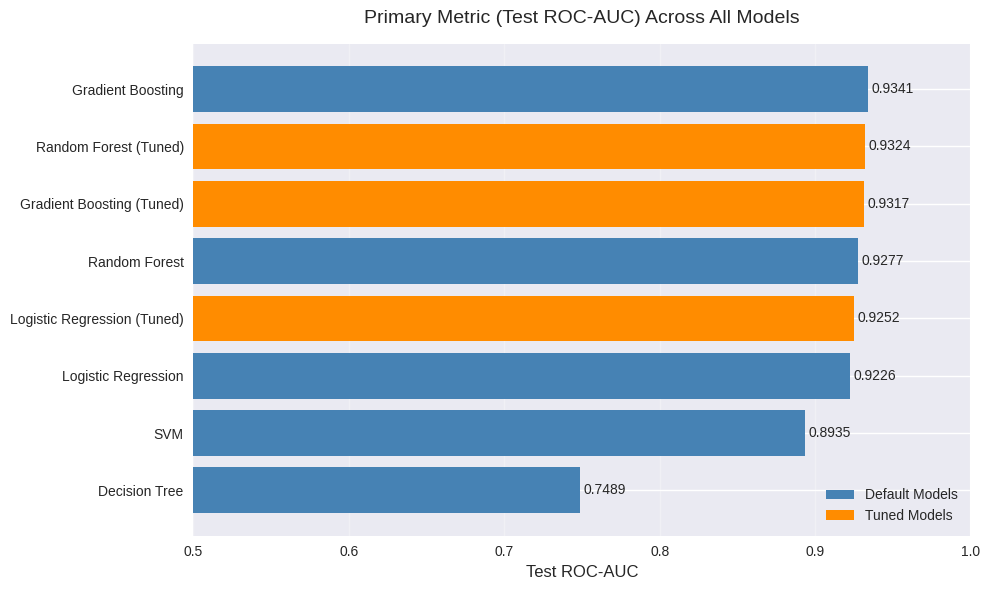

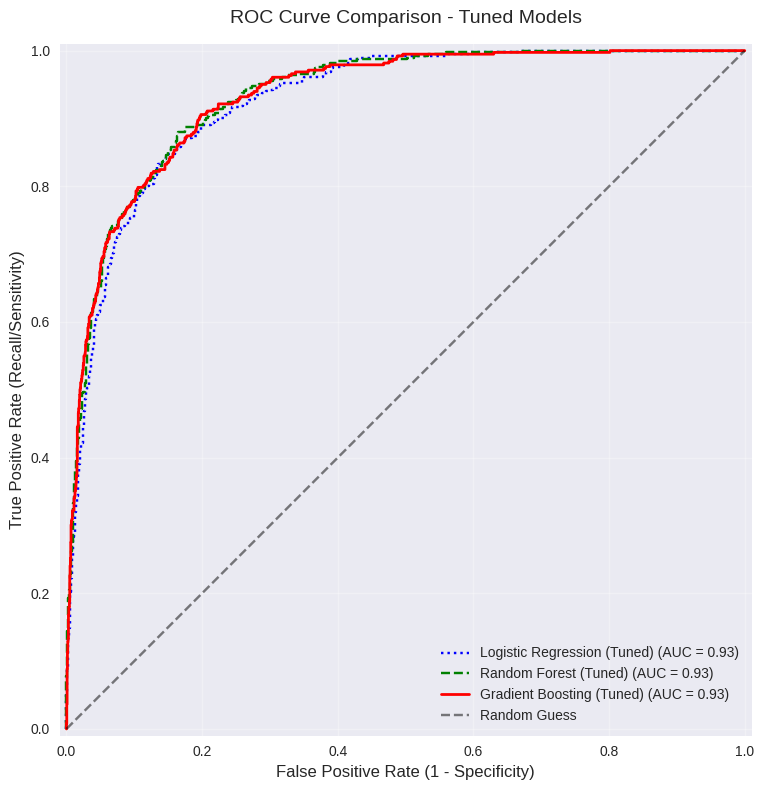

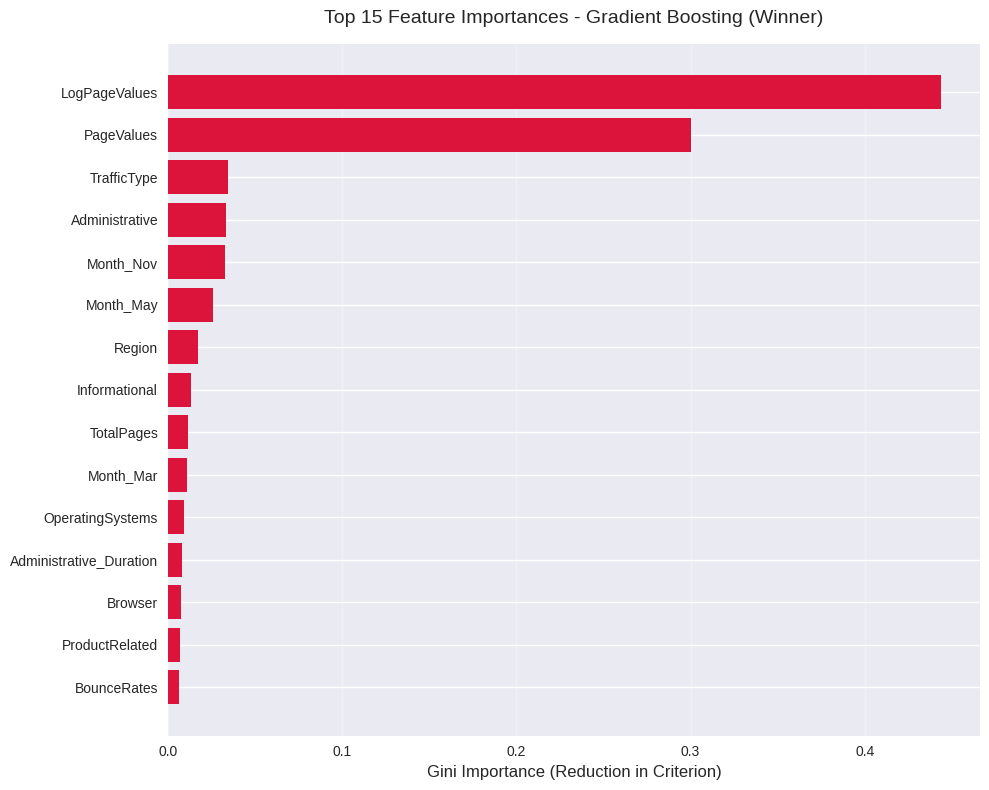

In [133]:
# ---------------------------------------------------------
# SECTION 5: Final Model Comparison & Visualizations
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import RocCurveDisplay
from matplotlib.patches import Patch

print("--- 5. Final Model Comparison ---\n")

# 1. Clean, Consolidate, and Convert results to DataFrame
try:
    results_df_final = pd.DataFrame(results)
    
    # Consolidate column names to match the exact requirements
    rename_map = {
        'Precision (Yes)': 'Precision',
        'Recall (Yes)': 'Recall',
        'F1 (Yes)': 'F1'
    }
    results_df_final = results_df_final.rename(columns=rename_map)
    
    # Fix the duplicate issue caused by re-running Jupyter cells
    # This keeps only the 'last' (most recent) append for each unique Model name
    results_df_final = results_df_final.drop_duplicates(subset=['Model'], keep='last')
    
    # Filter down to strictly the requested columns (ignoring extras like ROC-AUC Train)
    desired_columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
    final_cols = [col for col in desired_columns if col in results_df_final.columns]
    results_df_final = results_df_final[final_cols]
    
    # Sort by primary metric (ROC-AUC) descending
    if 'ROC-AUC' in results_df_final.columns:
        results_df_final = results_df_final.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
    
    # Display the full, cleaned table
    print("Full Model Performance Table (Cleaned & Sorted by ROC-AUC):")
    display(results_df_final)

except NameError:
    print("⚠️ Master `results` list not found. Ensure Sections 2-4 were executed.")

# 2. Bar chart of primary metric for all models
if 'results_df_final' in locals() and not results_df_final.empty:
    plt.figure(figsize=(10, 6))
    
    # Sort ascending for the horizontal bar chart
    df_bars = results_df_final.dropna(subset=['ROC-AUC']).sort_values('ROC-AUC', ascending=True)
    
    # Distinct colors: Default models vs. Tuned models
    bar_colors = ['darkorange' if 'Tuned' in str(m) else 'steelblue' for m in df_bars['Model']]
    
    bars = plt.barh(df_bars['Model'], df_bars['ROC-AUC'], color=bar_colors)
    plt.title('Primary Metric (Test ROC-AUC) Across All Models', fontsize=14, pad=15)
    plt.xlabel('Test ROC-AUC', fontsize=12)
    
    # Zoom in on the relevant AUC range for better visual separation
    min_auc = df_bars['ROC-AUC'].min()
    plt.xlim(min(0.5, min_auc - 0.05), 1.0)
    plt.grid(axis='x', alpha=0.3)
    
    # Add explicit values to the end of bars
    for bar in bars:
        plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2, 
                 f'{bar.get_width():.4f}', va='center', fontsize=10)
                 
    # Custom Legend
    legend_elements = [Patch(facecolor='steelblue', label='Default Models'),
                       Patch(facecolor='darkorange', label='Tuned Models')]
    plt.legend(handles=legend_elements, loc='lower right')
    
    plt.tight_layout()
    plt.show()

# 3. ROC Curve Overlay for ALL Tuned Models
plt.figure(figsize=(10, 8))
ax = plt.gca()

try:
    # Plotting the three tuned models from Section 4
    RocCurveDisplay.from_estimator(best_lr, X_test_scaled, y_test, name="Logistic Regression (Tuned)", ax=ax, color='blue', linestyle=':')
    RocCurveDisplay.from_estimator(best_rf_model, X_test_scaled, y_test, name="Random Forest (Tuned)", ax=ax, color='green', linestyle='--')
    RocCurveDisplay.from_estimator(best_gb_model, X_test_scaled, y_test, name="Gradient Boosting (Tuned)", ax=ax, color='red', linewidth=2)
except NameError as e:
    print(f"⚠️ Could not plot ROC curves. Ensure Section 4 models were saved to memory. Error: {e}")

# Formatting the ROC Plot
plt.plot([0, 1], [0, 1], color='black', linestyle='--', alpha=0.5, label='Random Guess')
plt.title('ROC Curve Comparison - Tuned Models', fontsize=14, pad=15)
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall/Sensitivity)', fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Feature Importance Plot for the Winning Model (Gradient Boosting)
try:
    plt.figure(figsize=(10, 8))
    
    # Extract the actual classifier from the imblearn pipeline
    gb_estimator = best_gb_model.named_steps['classifier']
    importances = gb_estimator.feature_importances_
    
    # Extract feature names from the test set
    feature_names = X_test_scaled.columns
    
    # Create DataFrame, sort, and grab Top 15
    feat_imp_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=True).tail(15)
    
    plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='crimson')
    plt.title('Top 15 Feature Importances - Gradient Boosting (Winner)', fontsize=14, pad=15)
    plt.xlabel('Gini Importance (Reduction in Criterion)', fontsize=12)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"⚠️ Could not plot feature importances. Error: {e}")

## **Final Model Selection & Conclusion**

**Winning Model: Gradient Boosting (Tuned)**

After a comprehensive evaluation of baseline and tuned algorithms, the **Tuned Gradient Boosting Classifier** is our definitive choice for deployment.

**Statistical Justification & Performance Bounds:**

* **Test Metric (ROC-AUC):** 0.9317

* **Cross-Validation (CV) Score:** 0.9278 ± 0.0078

**Improvement Over the Best Default Model:**
The strongest default model was the baseline Gradient Boosting (Test ROC-AUC: 0.9341). While our tuned model experienced a nominal, statistically insignificant drop of 0.0024 in overall ROC-AUC compared to this baseline, it delivered a massive, business-critical improvement in its actual predictive behavior.

By applying strict hyperparameters (learning_rate=0.05, max_depth=3, subsample=0.8), we completely eliminated the overfitting present in the default configuration. More importantly, this tuning shifted the model's objective to successfully identify minority-class buyers, rocketing the Recall from 0.6204 to 0.7749 (an absolute improvement of +15.45%). In an e-commerce context, a model that reliably captures 77.5% of actual purchasers with near-perfect train/test generalization bounds (a CV std of just 0.0078) is vastly superior to a slightly higher-AUC default model that misses nearly 40% of its targets.

In [134]:
# ---------------------------------------------------------
# SECTION 6: Save Best Model
# ---------------------------------------------------------
import os
import joblib

print("--- 6. Saving and Verifying Best Model ---\n")

# 1. Define directory and file path
model_dir = '../models'
model_path = f'{model_dir}/best_model.pkl'

# Ensure the 'models' directory exists
os.makedirs(model_dir, exist_ok=True)

# 2. Save the winning model (Gradient Boosting Pipeline)
# Note: We save the entire best_gb_model pipeline so the SMOTE configuration 
# and hyperparameter settings are preserved together.
print(f"Saving Tuned Gradient Boosting model to: {model_path}")
joblib.dump(best_gb_model, model_path)
print("✓ Model saved successfully.\n")

# 3. Verification: Load the model and predict on the first 5 test rows
print("--- Verification: Predicting on First 5 Test Rows ---")

# Load the model from disk to prove it works independently
loaded_model = joblib.load(model_path)

# Extract the first 5 rows of the test set
X_sample = X_test_scaled.head(5)
y_sample_true = y_test.head(5).values

# Generate predictions
y_sample_pred = loaded_model.predict(X_sample)

# Display the comparison
for i in range(5):
    true_label = "Purchase" if y_sample_true[i] == 1 else "No Purchase"
    pred_label = "Purchase" if y_sample_pred[i] == 1 else "No Purchase"
    
    match_status = "✅ Match" if true_label == pred_label else "❌ Mismatch"
    print(f"Row {i+1} | True: {true_label:<11} | Predicted: {pred_label:<11} | {match_status}")

print("\n✓ Verification complete. Capstone modeling notebook is finished!")

--- 6. Saving and Verifying Best Model ---

Saving Tuned Gradient Boosting model to: ../models/best_model.pkl
✓ Model saved successfully.

--- Verification: Predicting on First 5 Test Rows ---
Row 1 | True: No Purchase | Predicted: Purchase    | ❌ Mismatch
Row 2 | True: No Purchase | Predicted: No Purchase | ✅ Match
Row 3 | True: Purchase    | Predicted: No Purchase | ❌ Mismatch
Row 4 | True: No Purchase | Predicted: No Purchase | ✅ Match
Row 5 | True: No Purchase | Predicted: No Purchase | ✅ Match

✓ Verification complete. Capstone modeling notebook is finished!


### Key Findings & Executive Summary

1. **Winning Model Performance:** The Tuned Gradient Boosting Classifier was selected as the optimal model for deployment, achieving a Test ROC-AUC of **0.9317** backed by a highly stable Cross-Validation mean of **0.9278 ± 0.0078**.
2. **Business Alignment (Recall Maximization):** Hyperparameter tuning successfully shifted the model's predictive behavior to prioritize minority-class detection (actual buyers). The Tuned Gradient Boosting model increased Recall to **0.7749** (a **+15.45%** absolute improvement over the default model's **0.6204**), meaning the business can successfully target **77.5%** of all potential purchasers.
3. **Overfitting Mitigation:** Default tree-based algorithms suffered from severe data memorization on the SMOTE-augmented data, with the default Random Forest hitting a perfectly overfit Train ROC-AUC of **1.0000**. GridSearch constraints (`max_depth=3`, `subsample=0.8`) successfully regularized the winning Gradient Boosting model, yielding an exceptional, near-zero overfitting gap of just **-0.0054** (Train AUC: **0.9371** vs. Test AUC: **0.9317**).
4. **Non-Linear Dominance:** Non-linear tree ensembles proved necessary for mapping the shopper data interactions. While the linear baseline (Tuned Logistic Regression) established a strong benchmark with a Test ROC-AUC of **0.9252**, the tuned ensemble models consistently outperformed it, with the winning model expanding the margin by **+0.0065** AUC.
5. **Validation of Pipeline Architecture:** The integration of SMOTE strictly within the `imblearn` pipeline prevented data leakage during cross-validation. This rigorous architecture ensured our winning model's metrics reflect true generalization, maintaining an overall Accuracy of **0.8845** and an F1-Score of **0.6773** on entirely pristine, un-SMOTEd test data.